In [1]:
!pip -q install nilearn nibabel pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 24.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from nilearn import datasets, plotting
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm import threshold_stats_img

In [3]:
localizer = datasets.fetch_localizer_first_level()

fmri_img = localizer.epi_img
events = pd.read_csv(localizer.events, sep="\t")

contrast = "sentence_reading - sentence_listening"

[fetch_localizer_first_level] Added README.md to /root/nilearn_data

[fetch_localizer_first_level] Dataset created in /root/nilearn_data/localizer_first_level

[fetch_localizer_first_level] Downloading data from https://osf.io/2bqxn/download ...

[fetch_localizer_first_level]  ...done. (2 seconds, 0 min)

[fetch_localizer_first_level] Extracting data from 
/root/nilearn_data/localizer_first_level/cac0ef0f4307834e60fedd2a0448862a/download...

[fetch_localizer_first_level] .. done.

In [4]:
model = FirstLevelModel(
    t_r=2.4,
    slice_time_ref=0.5,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    smoothing_fwhm=5,
    minimize_memory=False
)

model = model.fit(fmri_img, events=events)
z_map = model.compute_contrast(
    contrast,
    output_type="z_score"
)

print("Model complete.")

Model complete.


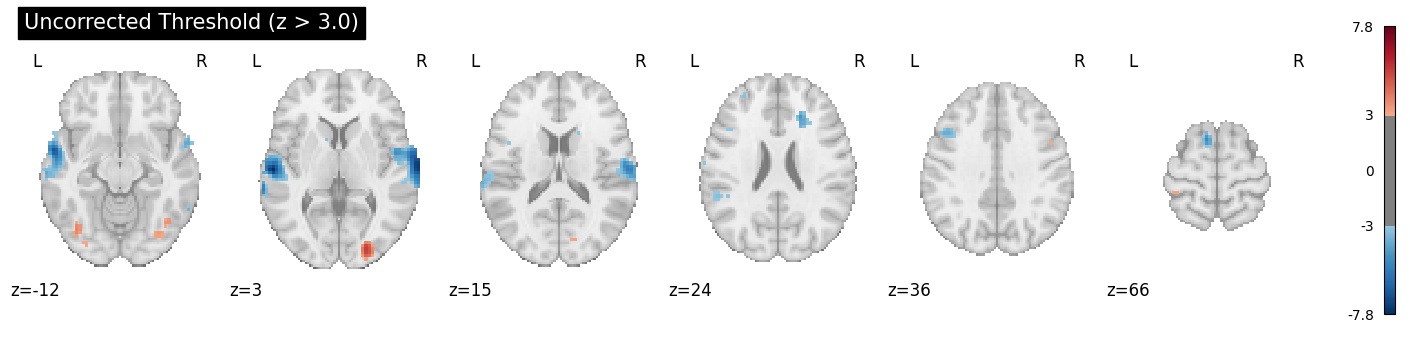

In [5]:
plotting.plot_stat_map(
    z_map,
    threshold=3.0,
    display_mode="z",
    cut_coords=6,
    title="Uncorrected Threshold (z > 3.0)"
)
plotting.show()

FDR threshold: 3.288787777785745


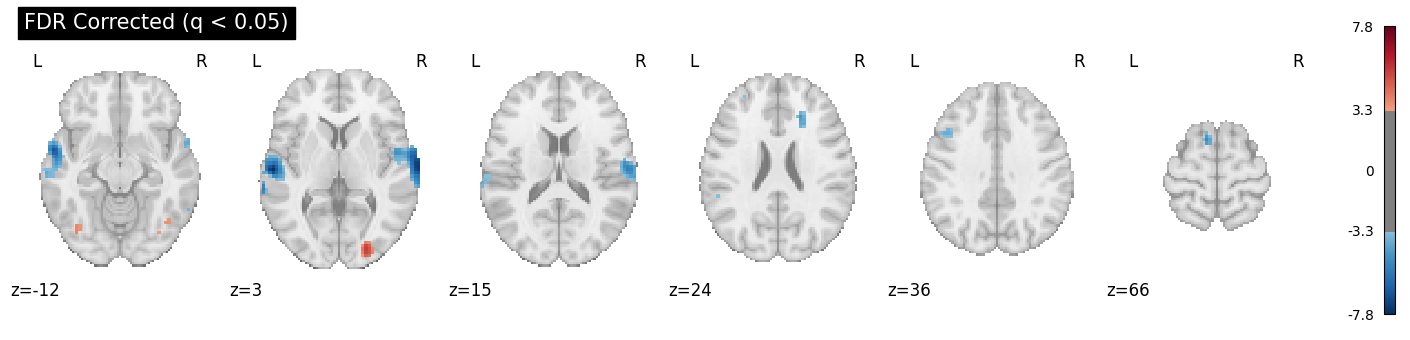

In [6]:
thresholded_map, threshold = threshold_stats_img(
    z_map,
    alpha=0.05,
    height_control="fdr"
)

print("FDR threshold:", threshold)

plotting.plot_stat_map(
    thresholded_map,
    threshold=threshold,
    display_mode="z",
    cut_coords=6,
    title="FDR Corrected (q < 0.05)"
)
plotting.show()

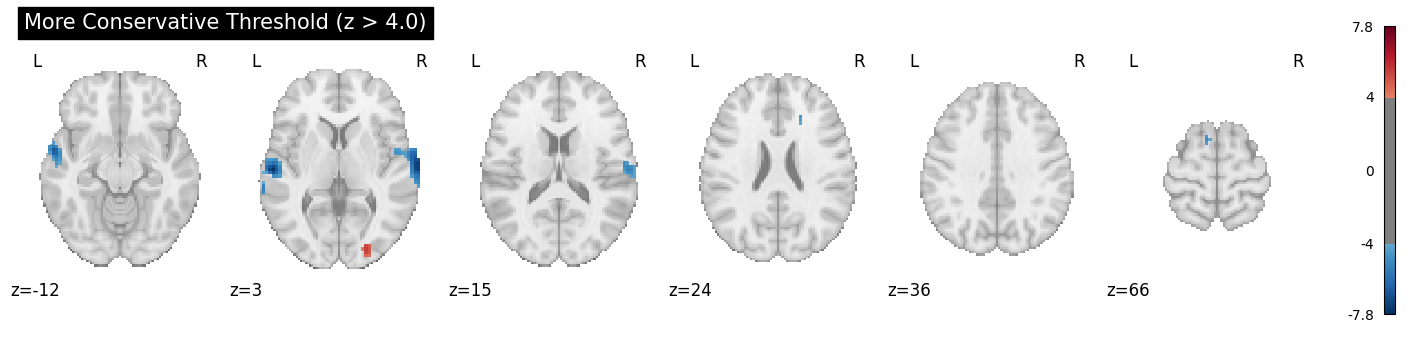

In [7]:
plotting.plot_stat_map(
    z_map,
    threshold=4.0,
    display_mode="z",
    cut_coords=6,
    title="More Conservative Threshold (z > 4.0)"
)
plotting.show()

In [ ]:
print("Inference comparison complete.")
print("Compare spatial extent across thresholding methods.")